<h11> From Notebook 1 that will guide this: severe imbalance (97.24%/2.76%), WORK_YEARS to be dropped, PAY_0–PAY_6 likely strong predictors, skewed BILL_AMT/PAY_AMT columns we're deliberately not transforming, and JOB_TYPE to be one-hot encoded later.

<h5> Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('dataset.csv')
target_col = 'default payment next month'

<h11> Fresh load, same as Notebook 1 - this notebook is independent so it can be run standalone. We're not doing any cleaning here (that's Notebook 3's job); EDA works on the raw data so we understand relationships before we start altering anything.

<h5> Demographics vs target: JOB_TYPE

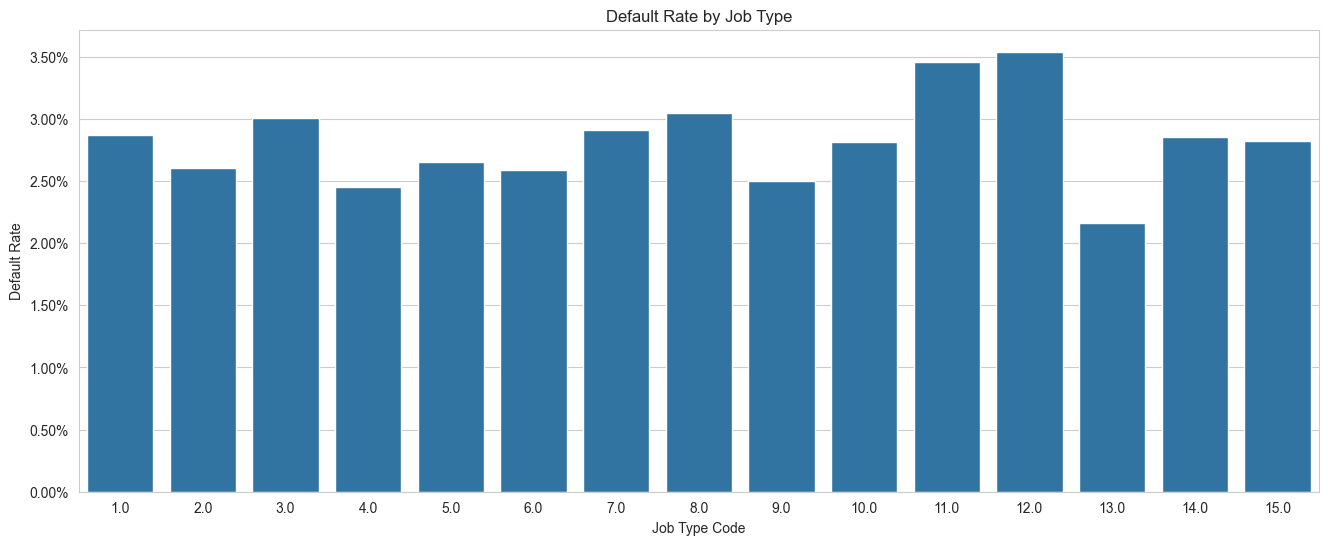

In [2]:
plt.figure(figsize=(16,6))
ax = sns.barplot(x='JOB_TYPE', y=target_col, data=df, errorbar=None)
plt.title('Default Rate by Job Type')
plt.xlabel('Job Type Code')
plt.ylabel('Default Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

<h8> The y-axis shows the default rate for each job type - the percentage of customers within that specific job type who defaulted, not the raw count of defaulters. This is calculated as the mean of the binary target column per group, which is mathematically equivalent to the proportion of defaulters in each category. Using rate instead of raw count ensures a fair comparison across job types regardless of group size, since larger job type groups would otherwise appear to have more defaults simply due to having more people. Job types 11 and 12 show the highest default rates (~3.5%), while job type 13 shows the lowest (~2.15%), indicating this feature does carry some predictive signal despite the relatively modest overall spread.

<h5>  Demographics vs target: SEX, EDUCATION, MARRIAGE

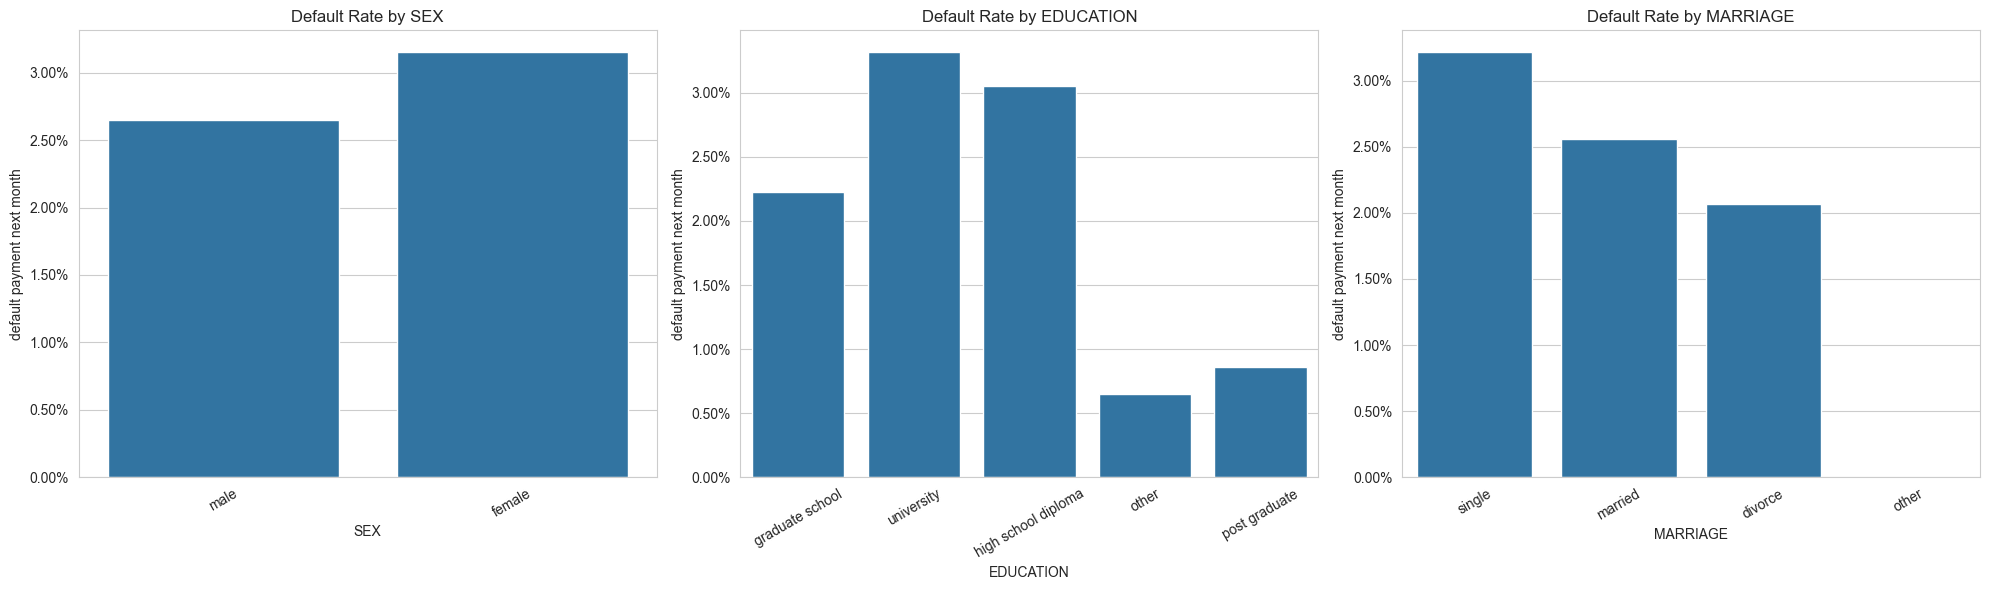

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))

for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    sns.barplot(x=col, y=target_col, data=df, errorbar=None, ax=ax)
    ax.set_title(f'Default Rate by {col}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<h11> 

- SEX: Female customers show a slightly higher default rate (~3.2%) than male (~2.5%) - matching the reference project's finding that female default rate was higher despite males having more total defaulters in raw count.
- EDUCATION: High school diploma holders show the highest default rate (~3.6%), followed by university (~2.9%) and graduate school (~2.2%). Post-graduate is lowest (~1.7%) - a fairly clean pattern: more education associates with lower default risk, consistent with the reference project's finding.
- MARRIAGE: Divorced customers show the highest default rate (~3.6%), single (~2.8%), married (~2.6%). Again matches the reference project's general direction (single/divorced riskier than married).

<h5> AGE distribution by target

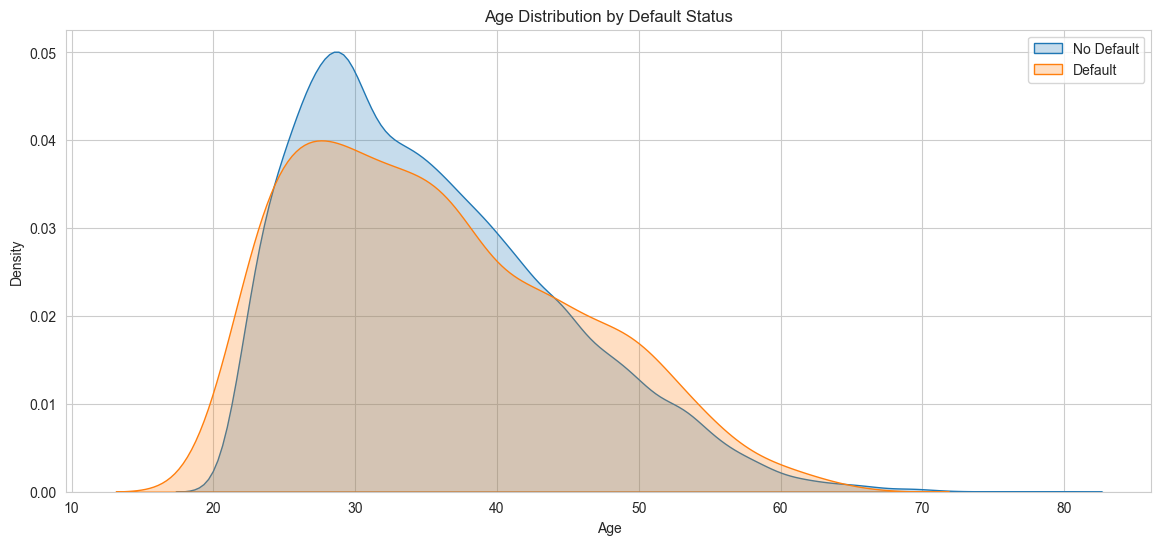

In [4]:
plt.figure(figsize=(14,6))
sns.kdeplot(df.loc[df[target_col]==0, 'AGE'], label='No Default', fill=True)
sns.kdeplot(df.loc[df[target_col]==1, 'AGE'], label='Default', fill=True)
plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.legend()
plt.show()

<h11> What the y-axis means: "Density" here isn't a probability or percentage directly — it's a smoothed estimate of how concentrated each group's ages are at every point, such that the total area under each curve sums to 1. So you're comparing shapes between the two groups, not raw counts (which is good, since we have 23,364 non-defaulters vs only 664 defaulters — plotting raw counts would make the defaulter curve invisible).
What the shapes show:

Both groups peak around the same place (~27-29 years old) — age doesn't shift the typical customer dramatically between groups.
Ages 20-25 (younger): the orange (Default) curve sits clearly above the blue (No Default) curve — younger customers are disproportionately represented among defaulters relative to non-defaulters.
Ages 30-45 (middle): blue sits above orange — this age range is disproportionately non-defaulters.
Ages 45-60+ (older): orange creeps back above blue again — older customers also show up disproportionately among defaulters.

Interpretation: age shows a mild U-shaped relationship with default risk — younger (20-25) and older (45-60) customers appear slightly riskier, while the 30-45 middle range looks like the "safest" segment. This is a weaker, more nuanced signal than something like PAY_0, but not nothing — it lines up with the earlier bar chart discovery (from the reference project's Age_Group_Bins analysis) that age groups 20-25 and 50-60 had the highest default rates.

<h5> PAY_0 through PAY_6 vs target (the likely strongest predictors)

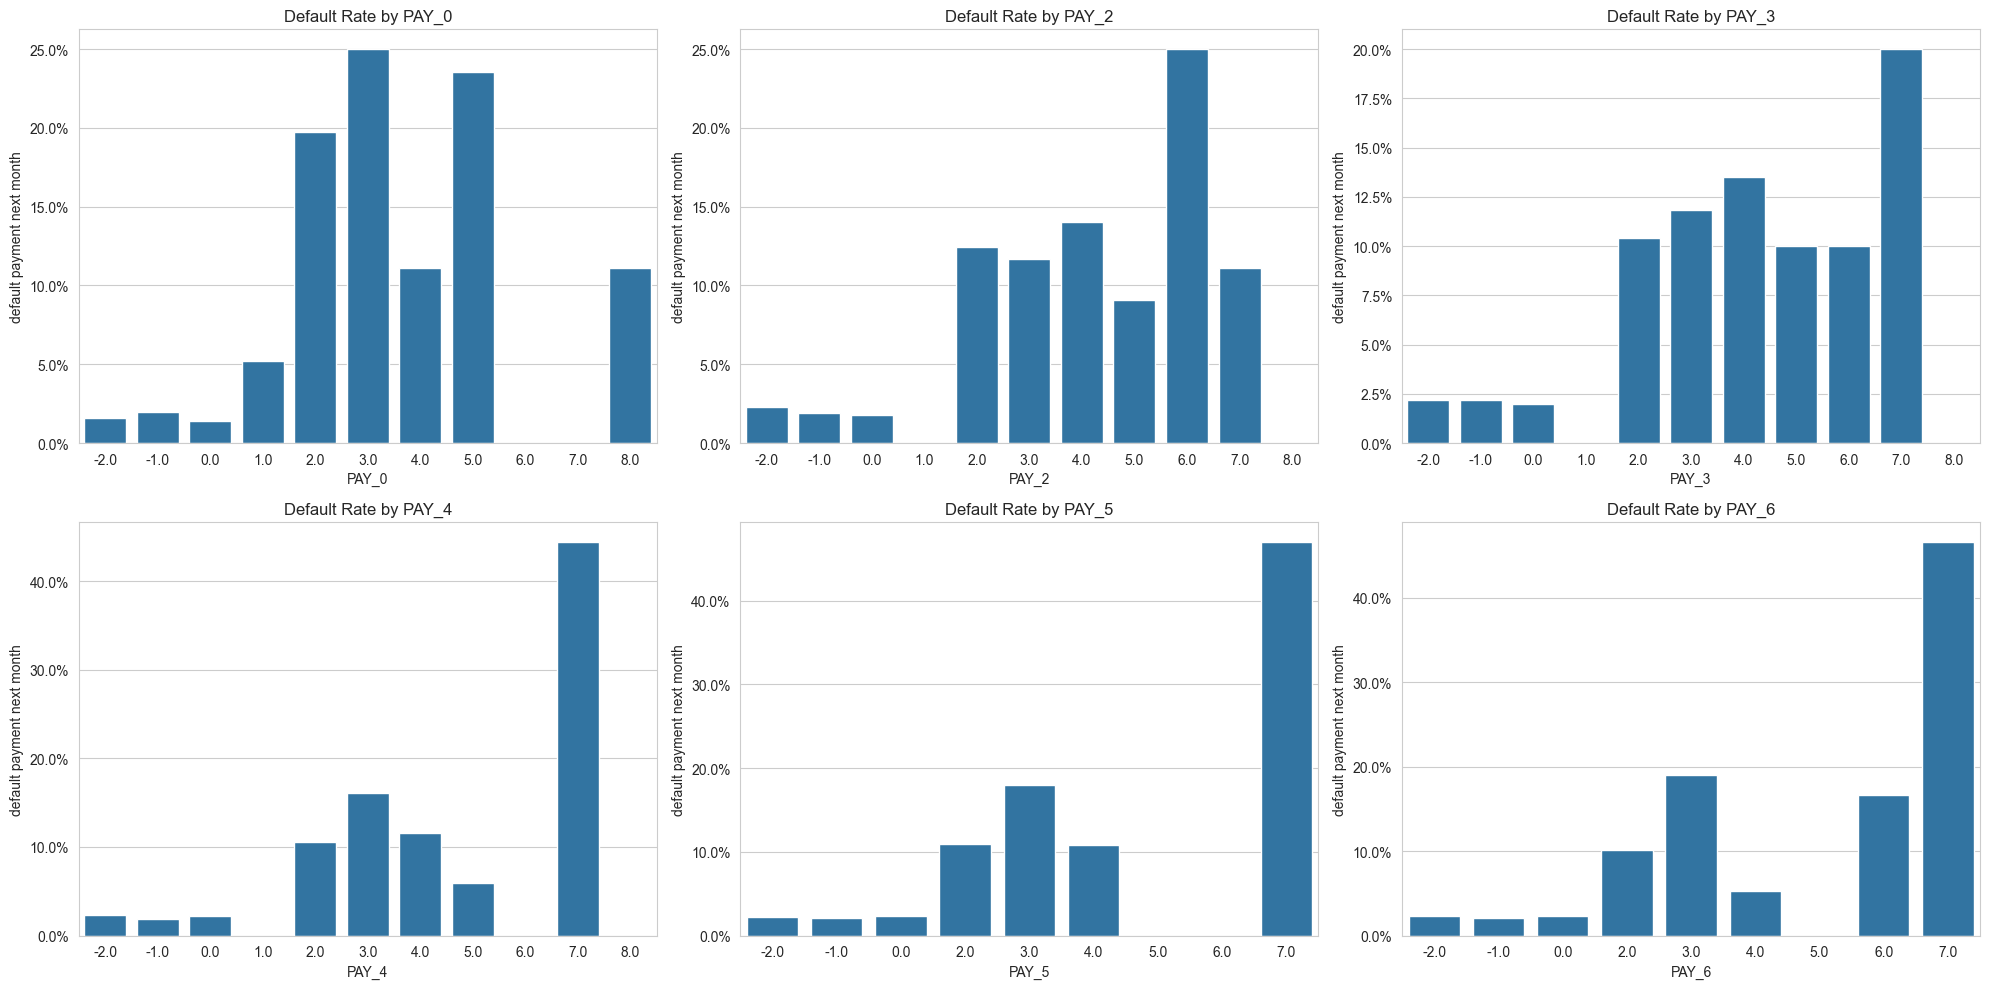

In [5]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(20,10))
axes = axes.flatten()

for ax, col in zip(axes, pay_cols):
    sns.barplot(x=col, y=target_col, data=df, errorbar=None, ax=ax)
    ax.set_title(f'Default Rate by {col}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

<h11> What the pattern shows across all six months:

Values -2, -1, 0 (paid early / duly / revolving credit, no delay): consistently the lowest default rate, flat around 1.5–2.5% across all six PAY columns — right in line with the overall base rate (2.76%).
Value 1 (1 month delay): only appears in PAY_0, jumps to ~5%.
Values 2 and above (2+ months delinquent): default rate jumps sharply, often 10-25%.
The highest delay codes (7, 8) in PAY_3–PAY_6 spike dramatically to 40-47% — meaning nearly half the customers with the most severe payment delays in a given month go on to default.

This is a huge finding for your project: these six columns show by far the strongest, most monotonic relationship with the target of anything we've looked at — default rate essentially rises step-by-step with delay severity. This strongly supports the "repayment history is the dominant predictor" narrative common in credit risk modeling, and you should expect these features to dominate the feature importance rankings once we get to modeling.

<h5> checking actual values

In [ ]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

pay_counts = pd.DataFrame({col: df[col].value_counts().sort_index() for col in pay_cols})
pay_counts

# pay_counts = pay_counts.fillna(0).astype(int)
# pay_counts

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2.0,2370,3080,3311,3503,3632.0,3890.0
-1.0,4671,5024,4975,4706,4579.0,4723.0
0.0,12630,13052,12893,13340,13660.0,13136.0
1.0,2488,22,3,1,NaN,NaN
2.0,1007,1930,1995,1632,1311.0,1462.0
3.0,96,137,110,81,78.0,79.0
4.0,27,57,37,26,37.0,19.0
5.0,17,11,10,17,6.0,6.0
6.0,5,4,10,3,1.0,6.0
7.0,2,9,5,18,17.0,15.0


<h8> This table confirms that most customers fall into the well-populated delay codes (-2, -1, 0), each with several thousand customers, making default rate estimates at these codes reliable. However, higher delay codes (3 and above) represent very small subgroups, some with fewer than 10 or even 0 customers (e.g., PAY_5 = 1 and PAY_6 = 1 have zero occurrences), meaning the sharp default rate spikes seen at these codes in the earlier plots are based on limited data and should be interpreted with caution rather than treated as precise estimates.

<h5> Correlation heatmap (numeric features only) (here we check for multicollinearity)

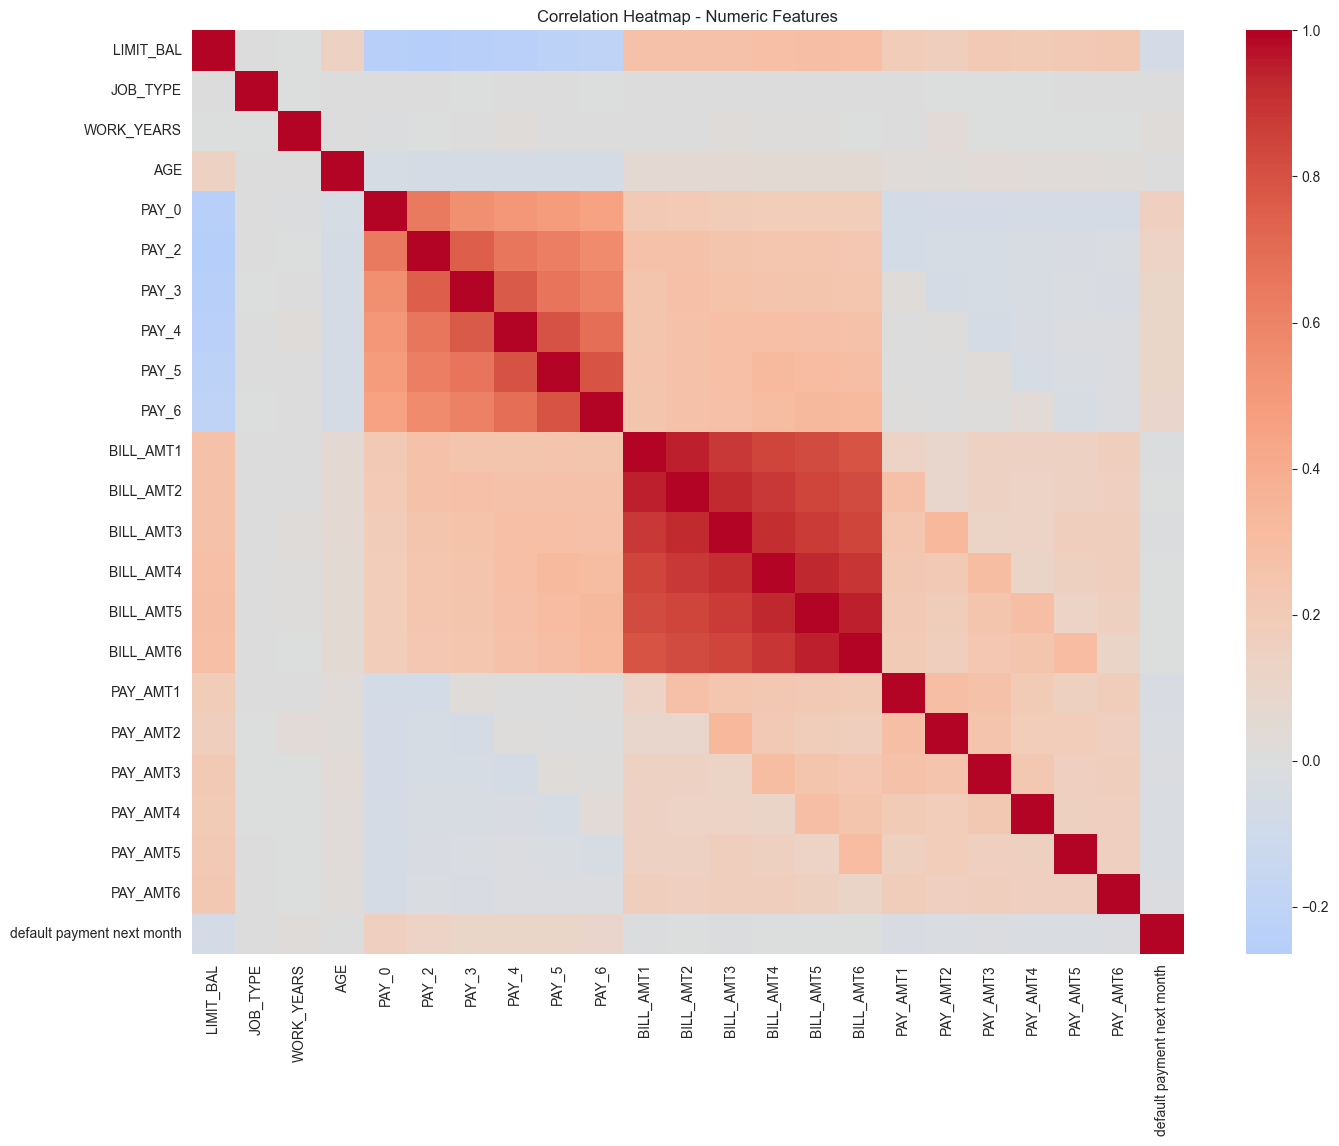

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('ID')

plt.figure(figsize=(16,12))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

<h11> 

1. BILL_AMT1–BILL_AMT6 form a strong, tight red block with each other (dark red squares, correlations likely 0.8-0.95+) — confirming these six columns are heavily redundant with each other. Makes sense: a customer's bill balance in April is a strong predictor of their bill balance in May, since balances carry over month to month.
2. PAY_0–PAY_6 also correlate moderately with each other (medium orange, likely 0.4-0.6 range) — a customer who was delinquent one month tends to stay somewhat delinquent in nearby months, but this cluster is noticeably less tightly correlated than the BILL_AMT block, meaning each month's payment status still carries some independent information.
3. PAY_AMT1–PAY_AMT6 show almost no correlation with each other (mostly grey/near-white, close to 0) — unlike bill amounts, how much someone pays one month tells you very little about how much they'll pay the next month. This makes intuitive sense (payment amount can vary a lot: sometimes minimum payment, sometimes full payoff).
4. LIMIT_BAL shows a mild negative correlation with PAY_0–PAY_6 (light blue) — higher credit limits are associated with better payment behavior (less delinquency), which lines up with typical credit risk intuition (banks give higher limits to lower-risk customers to begin with).
5. Correlation with the actual target (default payment next month, bottom row): this is the most important row for your project, and it's worth noting honestly — visually, none of the individual correlations with the target look strong (all appear pale/near-white in that bottom row), including PAY_0–PAY_6, despite the very clear default-rate pattern we saw in Block 5. That's not a contradiction — it's because Pearson correlation only measures linear relationships, while the PAY_x → default relationship is more of a threshold/step pattern (fine at low codes, jumps at high codes), which correlation coefficients don't capture well. Tree models pick up exactly this kind of non-linear, threshold-based relationship, which is precisely why they suit this problem better than linear models.
What this means for preprocessing/modeling decisions:

The tight BILL_AMT redundancy is worth mentioning as a candidate for dimensionality reduction (e.g., PCA) if you wanted to explore that as an extension — not required, since tree models tolerate collinearity reasonably well, but worth flagging as a known limitation/consideration in your report.
The weak linear correlation with target doesn't mean these features are weak predictors — it means correlation is the wrong lens for this kind of relationship, which is itself a useful point to make in your report to show you understand why you chose the evaluation/modeling approach you did.

<h5> Extracting exact correlation values

In [9]:
# Correlation of each feature with the target, sorted
target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print("Correlation with target (sorted by strength):")
print(target_corr)

Correlation with target (sorted by strength):
PAY_0         0.155781
PAY_2         0.127707
PAY_3         0.105763
PAY_4         0.105070
PAY_5         0.100614
PAY_6         0.095890
LIMIT_BAL    -0.064195
PAY_AMT1     -0.032515
PAY_AMT2     -0.024483
PAY_AMT4     -0.024135
PAY_AMT5     -0.024030
PAY_AMT3     -0.022002
WORK_YEARS    0.020005
PAY_AMT6     -0.019184
BILL_AMT1    -0.009256
BILL_AMT3    -0.008542
BILL_AMT2    -0.007962
BILL_AMT4    -0.006581
JOB_TYPE      0.004904
AGE           0.004103
BILL_AMT5    -0.003350
BILL_AMT6    -0.002022
Name: default payment next month, dtype: float64


<h11> Correlation with target: PAY_0 is the strongest single predictor by linear correlation (0.156), followed by PAY_2 through PAY_6 in a clean descending order (0.128 → 0.096) — matching their proximity to the prediction month (PAY_0 is the most recent month, PAY_6 the oldest). LIMIT_BAL is the strongest negative correlation (-0.064), confirming higher credit limits associate with lower default risk. Everything else — BILL_AMT*, PAY_AMT*, AGE, JOB_TYPE, WORK_YEARS — sits below |0.03|, essentially negligible in linear terms. This is genuinely useful confirmation: it validates that repayment status history dominates, and it explains why the heatmap's target row looked almost uniformly pale — even the "strongest" correlation here (0.156) is still fairly weak in absolute terms, since real signal here is non-linear/threshold-based, as we discussed.

In [10]:
# Highest pairwise correlations among BILL_AMT columns
bill_cols = [c for c in numeric_cols if c.startswith('BILL_AMT')]
print("\nBILL_AMT pairwise correlations:")
print(corr.loc[bill_cols, bill_cols])


BILL_AMT pairwise correlations:
           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1   1.000000   0.946294   0.882629   0.847981   0.818538   0.791956
BILL_AMT2   0.946294   1.000000   0.922140   0.883345   0.851274   0.823519
BILL_AMT3   0.882629   0.922140   1.000000   0.915333   0.873882   0.843877
BILL_AMT4   0.847981   0.883345   0.915333   1.000000   0.934285   0.894533
BILL_AMT5   0.818538   0.851274   0.873882   0.934285   1.000000   0.942609
BILL_AMT6   0.791956   0.823519   0.843877   0.894533   0.942609   1.000000


<h11> BILL_AMT pairwise correlations: Adjacent months are most correlated (BILL_AMT4-BILL_AMT5: 0.934, BILL_AMT5-BILL_AMT6: 0.943), and correlation decays the further apart two months are (BILL_AMT1-BILL_AMT6: only 0.792, still very high, but the lowest in the block). This is a very tight cluster overall — every single pair is above 0.79 — strong evidence of redundancy.

In [11]:
# Highest pairwise correlations among PAY_0-PAY_6 columns
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print("\nPAY status pairwise correlations:")
print(corr.loc[pay_status_cols, pay_status_cols])


PAY status pairwise correlations:
          PAY_0     PAY_2     PAY_3     PAY_4     PAY_5     PAY_6
PAY_0  1.000000  0.645658  0.547264  0.513174  0.486522  0.451610
PAY_2  0.645658  1.000000  0.750320  0.656003  0.614841  0.562078
PAY_3  0.547264  0.750320  1.000000  0.763601  0.668248  0.612016
PAY_4  0.513174  0.656003  0.763601  1.000000  0.800816  0.692088
PAY_5  0.486522  0.614841  0.668248  0.800816  1.000000  0.796435
PAY_6  0.451610  0.562078  0.612016  0.692088  0.796435  1.000000


<h11> PAY status pairwise correlations: Much more moderate and more variable than BILL_AMT — ranges from 0.45 (PAY_0-PAY_6, furthest apart in time) to 0.80 (PAY_4-PAY_5, adjacent months). Same "closer months correlate more" pattern, but nowhere near as extreme as BILL_AMT — confirming each month's payment status does carry meaningfully independent information, unlike the bill amounts.

<h5>  LIMIT_BAL distribution by target

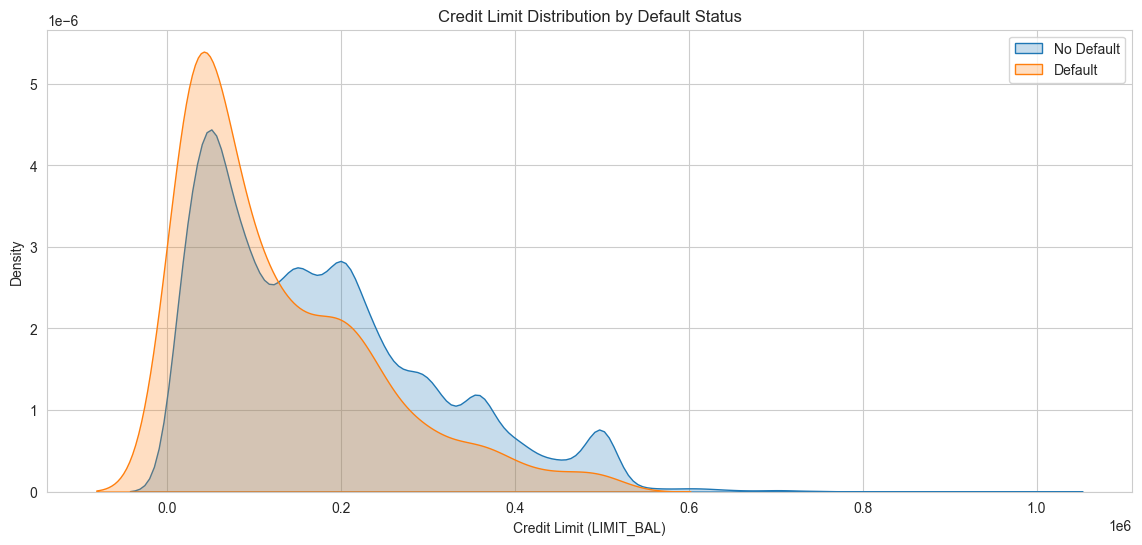

In [12]:
plt.figure(figsize=(14,6))
sns.kdeplot(df.loc[df[target_col]==0, 'LIMIT_BAL'], label='No Default', fill=True)
sns.kdeplot(df.loc[df[target_col]==1, 'LIMIT_BAL'], label='Default', fill=True)
plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Credit Limit (LIMIT_BAL)')
plt.legend()
plt.show()

<h11> LIMIT_BAL: Defaulters (orange) are more concentrated at lower credit limits — their curve peaks higher and drops off faster below ~150K, while non-defaulters (blue) have noticeably more mass spread out into the 150K-600K range (that bump around 200K, and the small peak around 500K, are both blue-dominant). So the pattern is consistent with the -0.064 correlation: higher credit limits are associated with lower default risk, and this holds up visually, not just as a small numeric artifact.

<h5> Representative BILL_AMT and PAY_AMT check (one column each)

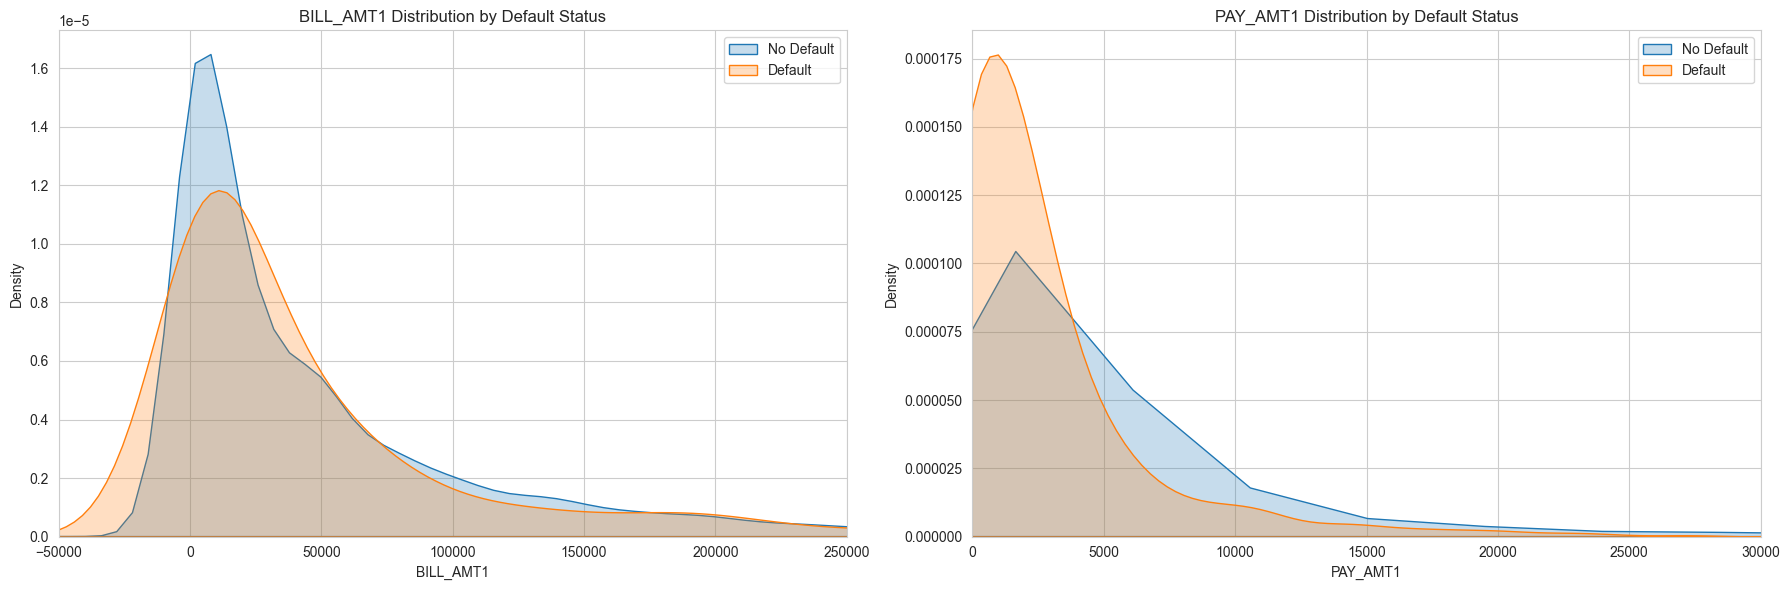

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.kdeplot(df.loc[df[target_col]==0, 'BILL_AMT1'], label='No Default', fill=True, ax=axes[0])
sns.kdeplot(df.loc[df[target_col]==1, 'BILL_AMT1'], label='Default', fill=True, ax=axes[0])
axes[0].set_title('BILL_AMT1 Distribution by Default Status')
axes[0].set_xlim(-50000, 250000)
axes[0].legend()

sns.kdeplot(df.loc[df[target_col]==0, 'PAY_AMT1'], label='No Default', fill=True, ax=axes[1])
sns.kdeplot(df.loc[df[target_col]==1, 'PAY_AMT1'], label='Default', fill=True, ax=axes[1])
axes[1].set_title('PAY_AMT1 Distribution by Default Status')
axes[1].set_xlim(0, 30000)
axes[1].legend()

plt.tight_layout()
plt.show()

<h11> 

1. BILL_AMT1: Very similar shapes between the two groups, with a modest difference — non-defaulters have a sharper, higher peak at low bill amounts (~10-15K) and a longer tail into higher amounts, while defaulters are slightly more spread toward the low-to-mid range. It's a real but subtle difference, consistent with the near-zero (-0.009) correlation — this confirms rather than contradicts the correlation number. No hidden non-linear surprise here, unlike what we found with PAY_0-6.
2. PAY_AMT1: Similar story — defaulters skew slightly more toward very low payment amounts (the orange peak is higher and further left, closer to 0), while non-defaulters have a flatter, more spread-out distribution extending further right. Again a real but modest difference (-0.033 correlation), and the shapes are similar enough that this doesn't reveal a hidden strong relationship either.

<h11> Notebook 2 (EDA) Summary: The dataset shows severe class imbalance (2.76% defaulters), motivating the resampling techniques explored later in this project. Repayment status features (PAY_0–PAY_6) show the clearest relationship with default, both through visibly rising default rates at higher delay codes and the strongest linear correlations among all features (PAY_0: 0.156), though the sharpest spikes at extreme delay codes stem from very small subgroups and should be interpreted cautiously. Credit limit (LIMIT_BAL) shows a modest but consistent negative relationship with default risk. Demographic features (SEX, EDUCATION, MARRIAGE, AGE, JOB_TYPE) show real but comparatively weak signal, with higher education and higher age (outside a 20-25 and 45-60 U-shape) associated with lower default rates. Bill and payment amount features (BILL_AMT1–BILL_AMT6, PAY_AMT1–PAY_AMT6) show minimal linear correlation with the target, confirmed by direct distribution comparison rather than correlation alone; however, BILL_AMT columns are highly redundant with one another (pairwise correlations above 0.79), a consideration for potential dimensionality reduction, while PAY_AMT columns are largely independent of each other.

<h11>

Quick recap of what we've built and locked in:
- Explored JOB_TYPE vs target — found real but modest separation in default rate (2.15%–3.55%), supporting the one-hot encoding decision
- Explored SEX, EDUCATION, MARRIAGE vs target — found mild but real signal (e.g., higher education and marriage associated with lower default rates)
- Explored AGE vs target — found a mild U-shaped relationship, with younger (20-25) and older (45-60) customers showing slightly elevated risk
- Explored PAY_0–PAY_6 vs target — found the strongest, most consistent signal in the dataset, with default rate rising sharply at higher delay codes; also checked category counts and flagged that the most extreme spikes come from very small subgroups
- Built a correlation heatmap and extracted exact values — confirmed PAY_0–PAY_6 as the strongest linear predictors, found BILL_AMT1–6 highly redundant with each other (>0.79 pairwise), and PAY_AMT columns largely independent of each other
- Explored LIMIT_BAL and representative BILL_AMT/PAY_AMT distributions by target — confirmed the near-zero correlations for BILL_AMT/PAY_AMT genuinely reflect weak relationships, not a hidden non-linear pattern missed by correlation
- Closed with a written summary tying all findings together, ready to carry into the report's EDA section